In [76]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import re
import html
# import matplotlib.pyplot as plt

# from sklearn.datasets import fetch_20newsgroups

# import tensorflow as tf 
# from tensorflow import keras
# from keras.utils import plot_model
# from keras.initializers import GlorotUniform
# from keras.models import Sequential
# from keras import layers, models
# from keras.utils import load_img, img_to_array
# from keras import regularizers

# 1. Preprocesamiento de los Datos

## 1.1. Extracción de datos

El primer paso a realizar dentro de un entrenamiento e implementación de un modelo de Red Neuronal es extraer aquellos datos que se van a emplear dentro del entrenamiento del modelo.

En este caso, vamos a importar los datos empleados dentro de la práctica a través de un keras

In [77]:
df = pd.read_csv("news_dataset.csv")

In [78]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Ahora vamos a explorar el dataset en busca de cuantos elementos hay en todo el csv, cuantas clases hay en la columna de `Class Index` para hacernos una idea de a cuantas clases no vamos a enfrentar.

In [79]:
df.shape

(120000, 3)

In [80]:
# Ver cuántas noticias hay de cada categoría
df['Class Index'].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

## 1.2 Previsualizar los datos

Una vez realizada la extraccion de los datos y viendo cuantas clases hay, vamos a visualizar las clases con las proporciones de cada una.

C:\Users\sluis\AppData\Local\Temp\ipykernel_13924\3946130902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class Index', data=df, palette='viridis')


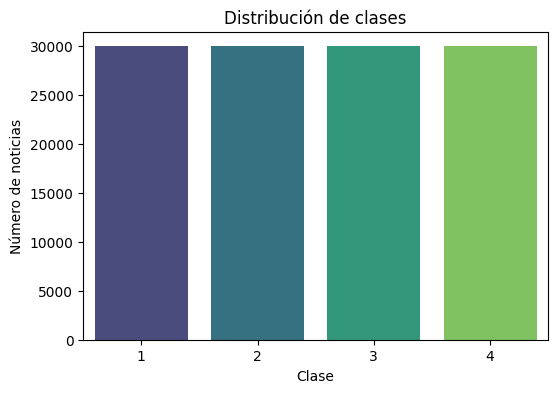

In [81]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class Index', data=df, palette='viridis')
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Número de noticias')
plt.show()

Vemos que las cuatro clases estan completamente balanceadas teniendo en las cuatro el mismo numero de noticias por categoria.

El data set es AG News, un corpus estándar de NLP. Las clases son las siguientes:

- 1 -> World (noticias del mundo / política)
- 2 -> Sports (deportes)
- 3 -> Business (ecnomía)
- 4 -> Sci/Tech (ciencia y tecnología)

Despues de una vista general de las clases y que contiene cada una vamos a ver como de largas son las descripciones para ver como va a afectar al procesamiento.

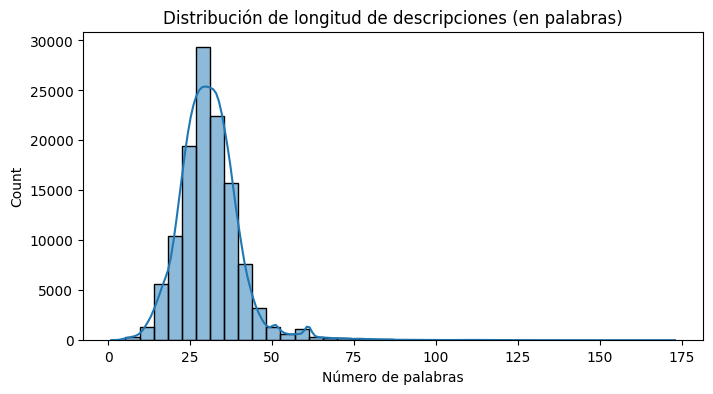

count    120000.000000
mean         31.060508
std           9.760460
min           1.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
Name: longitud, dtype: float64


In [82]:
df['longitud'] = df['Description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df['longitud'], bins=40, kde=True)
plt.title('Distribución de longitud de descripciones (en palabras)')
plt.xlabel('Número de palabras')
plt.show()

print(df['longitud'].describe())

In [83]:
# Ver exactamente qué contienen esas filas
df[(df['longitud'] > 9) & (df['longitud'] <= 10)][['Description']].values


array([['Former Gateway executive to lead consumer marketing efforts at Hewlett-Packard.'],
       ['Services try different approaches to sender authentication to halt spam.'],
       ['PC World - Chip maker postpones yet another product launch.'],
       ['Saudi visitors to Malaysia were up 53 percent in 2004.'],
       ['Consumer electronics prices still drop, mostly, but not so much.'],
       ['The government gives the green-light to internet-only pharmacies in England.'],
       ['Automaker dumps Everest procurement system to revert to older technologies.'],
       ['PC World - Free software helps organize large music collections.'],
       ["Grokster, Morpheus not liable for user's actions, appeals court says."],
       ["Britain's Alison Sheppard coasts into the women's 50m freestyle semi-finals."],
       ['Trauma and malnutrition leave many refugee mothers unable to breast-feed.'],
       ["Yachting is one of the new luxuries for Moscow's superrich."],
       ['By RACHEL KONRA

In [84]:
# Ver exactamente qué contienen esas filas
df[(df['longitud'] > 3) & (df['longitud'] <= 5)][['Description']].values

array([['&lt;strong&gt;Opinion&lt;/strong&gt; SAP hardly to blame'],
       ['&lt;strong&gt;Competition&lt;/strong&gt; Get those suggestions in'],
       ['&lt;strong&gt;HP World&lt;/strong&gt; SAP hell lingers'],
       ['&lt;strong&gt;Analysis&lt;/strong&gt; Lost in Space'],
       ['&lt;strong&gt;LogoWatch&lt;/strong&gt; Unpleasant, but not fatal'],
       ['Home Office redefines statistical invalidity'],
       [' INTEL CORP.&lt;A HREF="http://www.investor.reuters.com/FullQuote.aspx?ticker=INTC.O target=/stocks/quickinfo/fullquote"&gt;INTC.O&lt;/A&gt;:'],
       ["&lt;strong&gt;IDF Fall '04&lt;/strong&gt; Welcome Whitefield"],
       ["&lt;strong&gt;IDF Fall '04&lt;/strong&gt; Well, soon-ish"],
       [' ORACLE CORP. &lt;A HREF="http://www.investor.reuters.com/FullQuote.aspx?ticker=ORCL.O target=/stocks/quickinfo/fullquote"&gt;ORCL.O&lt;/A&gt;:'],
       [' COCA-COLA CO. &lt;A HREF="http://www.investor.reuters.com/FullQuote.aspx?ticker=KO.N target=/stocks/quickinfo/fullquote"&gt;KO

In [85]:
# # ¿Cuántas hay?
# print(df[df['longitud'] <= 9].shape[0])

df = df[df['longitud'] > 9]

In [86]:
df.shape

(119602, 4)

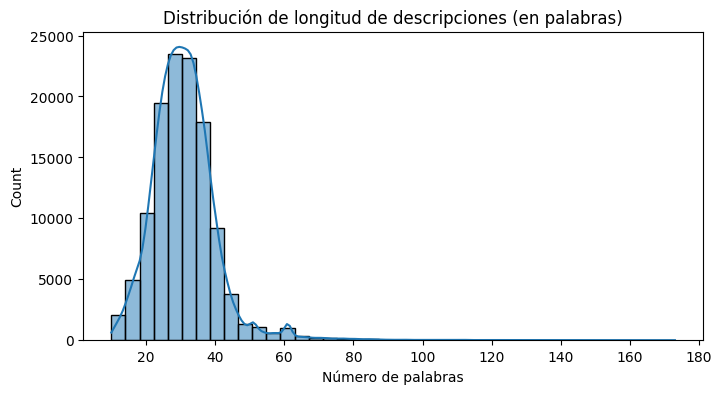

count    119602.000000
mean         31.140223
std           9.677657
min          10.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
Name: longitud, dtype: float64


In [87]:
df['longitud'] = df['Description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df['longitud'], bins=40, kde=True)
plt.title('Distribución de longitud de descripciones (en palabras)')
plt.xlabel('Número de palabras')
plt.show()

print(df['longitud'].describe())